In [ ]:
import os
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
from datautils import normalize, resample, R_Peaks, trial2sample, sample2trial

In [ ]:
# specify the root path
path = "../mimic-iv-ecg/1.0"
measurement_path = os.path.join(path, "machine_measurements.csv")
measurement_dict_path = os.path.join(path, "machine_measurements_data_dictionary.csv")
record_list_path = os.path.join(path, "record_list.csv")
note_links_path = os.path.join(path, "waveform_notes_links.csv")
record_path = os.path.join(path, "RECORDS")

In [ ]:
record_list = pd.read_csv(record_list_path)
subset_list = record_list[record_list["path"].str.contains(r"files/p10[0-9]{2}/")]
# subset_list = record_list[record_list["subject_id"].isin(record_list["subject_id"].drop_duplicates().head(16000))]
subset_list # directly use record_list for all records

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569
...,...,...,...,...,...
34148,10439110,46049836,46049836,2146-03-23 17:51:00,files/p1043/p10439110/s46049836/46049836
34149,10439110,42844489,42844489,2146-03-24 07:57:00,files/p1043/p10439110/s42844489/42844489
34150,10439110,44635758,44635758,2146-04-02 06:25:00,files/p1043/p10439110/s44635758/44635758
34151,10439110,43341581,43341581,2146-04-02 23:42:00,files/p1043/p10439110/s43341581/43341581


In [19]:
measurement = pd.read_csv(measurement_path)
subset_measurement = measurement[measurement["subject_id"].isin(subset_list["subject_id"].drop_duplicates())]
subset_measurement # directly use measurement for all records

/tmp/ipykernel_143326/1472196822.py:1: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  measurement = pd.read_csv(measurement_path)


,subject_id,study_id,cart_id,ecg_time,report_0,report_1,report_2,report_3,report_4,report_5,...,filtering,rr_interval,p_onset,p_end,qrs_onset,qrs_end,t_end,p_axis,qrs_axis,t_axis
0,10000032,40689238,6848296,2180-07-23 08:44:00,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,...,60 Hz notch Baseline filter,659,40,128,170,258,518,81,77,79
1,10000032,44458630,6848296,2180-07-23 09:54:00,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,...,60 Hz notch Baseline filter,722,40,124,162,246,504,77,75,70
2,10000032,49036311,6376932,2180-08-06 09:07:00,Sinus tachycardia,NaN,Normal ECG except for rate,NaN,NaN,NaN,...,60 Hz notch Baseline filter,600,40,130,162,244,474,79,72,77
3,10000117,45090959,6214760,2181-03-04 17:14:00,Sinus rhythm,NaN,Normal ECG,NaN,NaN,NaN,...,60 Hz notch Baseline filter,659,40,146,180,254,538,79,66,69
4,10000117,48446569,6632385,2183-09-18 13:52:00,Sinus rhythm,NaN,NaN,NaN,NaN,NaN,...,<not specified>,659,368,29999,504,590,868,84,80,77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34148,10439110,44635758,6632385,2146-04-02 06:25:00,"Age not entered, assumed to be 50 years old f...",Sinus rhythm,NaN,NaN,NaN,NaN,...,<not specified>,645,371,29999,509,604,883,22,32,60
34149,10439110,43341581,6632385,2146-04-02 23:42:00,Sinus tachycardia,Ventricular bigeminy,"Prominent P waves, nondiagnostic",Left bundle branch block,NaN,NaN,...,<not specified>,594,367,29999,508,655,858,0,-18,199
34150,10439110,40202749,6610295,2146-04-03 02:27:00,Accelerated idioventricular rhythm.,IV conduction defect,Extensive ST-T changes may be due to myocardia...,NaN,Abnormal ECG,NaN,...,60 Hz notch Baseline filter,895,29999,29999,200,336,626,29999,41,99
34151,10439110,40209355,6632385,2151-04-28 12:12:00,Sinus tachycardia,Left bundle branch block,NaN,NaN,NaN,NaN,...,<not specified>,500,390,29999,499,655,931,-6,-13,121


In [20]:
# group signals by order of patient
group = subset_list.groupby("subject_id")["study_id"].apply(list)
group

subject_id
10000032                       [40689238, 44458630, 49036311]
10000117                                 [45090959, 48446569]
10000285                                           [42709053]
10000560                                 [41445586, 42695383]
10000635    [40067704, 48339811, 45386375, 43522917, 44095...
                                  ...                        
10438951    [49948089, 44529507, 49155589, 47315062, 43749...
10439001    [48483321, 46676467, 45464020, 48287289, 43017...
10439029                                 [44383103, 46956684]
10439079                                           [46127417]
10439110    [43668457, 46668015, 46005275, 45447450, 47845...
Name: study_id, Length: 7000, dtype: object

In [ ]:
# get median R-Peak intervals for all trials, drop trials that contains nan or all zero
med_intervals = []
abnormal_trial = []
nan_trial = []
allzero_trial = []
for pid, tris in group.items():
    for tri in tris:
        tri_path = os.path.join(path, subset_list.loc[subset_list.study_id == tri].path.values[0])
        ecg_data = wfdb.rdsamp(record_name=tri_path)[0]
        if np.all(ecg_data == 0):
            allzero_trial.append(tri_path)
            print(f"All zero: {tri_path}")
            continue
        if np.any(np.isnan(ecg_data)):
            nan_trial.append(tri_path)
            print(f"Nan: {tri_path}")
            continue
        trial = []
        for ch in range(ecg_data.shape[1]):
            data = resample(ecg_data[:,ch], freq1=500, freq2=250, kind="linear")
            trial.append(data)
        trial = np.array(trial).T
        trial_norm = normalize(trial)
        try:
            _, med, _ = R_Peaks(trial_norm)
            med_intervals.append(med.to_list())
        except IndexError:
            print(f"The trial is invalid with trial path {tri_path}")
            abnormal_trial.append(tri_path)
            pass
            
print(len(abnormal_trial), len(nan_trial), len(allzero_trial))
df_med_intervals = pd.DataFrame(med_intervals).T
df_med_intervals

In [22]:
# 15820 records suitable for analysis
all_med = df_med_intervals.median()
print(all_med[all_med<=300].shape)
print(all_med[all_med<=300].max())
max_duration = 300

(32720,)
300.0


In [ ]:
# remove records that have median interval length greater than max duration
med_intervals = []
abnormal_trial = []
med_nan_trial = []
drop_trial = nan_trial + allzero_trial
for pid, tris in group.items():
    for tri in tris:
        tri_path = os.path.join(path, subset_list.loc[subset_list.study_id == tri].path.values[0])
        if tri_path in drop_trial:
            continue
        ecg_data = wfdb.rdsamp(record_name=tri_path)[0]
        trial = []
        for ch in range(ecg_data.shape[1]):
            data = resample(ecg_data[:,ch], freq1=500, freq2=250, kind="linear")
            trial.append(data)
        trial = np.array(trial).T
        trial_norm = normalize(trial)
        try:
            _, med, _ = R_Peaks(trial_norm)
            if med.median() <= max_duration:
                # if np.any(np.isnan(med)):
                #     med_nan_trial.append(tri_path)
                #     print(f"Med Nan: {tri_path}")
                #     continue 
                med_intervals.append(med.to_list())
            else:
                print(f"The trial is an outlier with trial path {tri_path}")
                abnormal_trial.append(tri_path)
        except IndexError:
            print(f"The trial is invalid with trial path {tri_path}")
            abnormal_trial.append(tri_path)
            pass
            
print(len(abnormal_trial), len(med_nan_trial))
df_med_intervals = pd.DataFrame(med_intervals).T
df_med_intervals

In [ ]:
# specify the path to save
save_path = "../dataset/mimic"
feature_path = os.path.join(save_path, "feature")
if not os.path.exists(feature_path):
    os.makedirs(feature_path)

dict_label = {}
sub_id = 1
drop_trial = drop_trial + abnormal_trial + med_nan_trial
none_trial = []
for pid, tris in group.items():
    li_sub_segs = []
    for tri in tris:
        tri_path = os.path.join(path, subset_list.loc[subset_list.study_id == tri].path.values[0])
        if tri_path in drop_trial:
            continue
        label = 0
        dict_label[sub_id] = label
        ecg_data = wfdb.rdsamp(record_name=tri_path)[0] # data
        trial = []
        for ch in range(ecg_data.shape[1]):
            data = resample(ecg_data[:,ch], freq1=500, freq2=250, kind="linear")
            trial.append(data)
        trial = np.array(trial).T
        trial_norm = normalize(trial)
        samples = trial2sample(trial_norm, max_duration=300)
        segmentations = sample2trial(samples, size=10) # all segmentations of a trial
        for seg in segmentations:
            li_sub_segs.append(seg)
                    
    if li_sub_segs != list(): # Not None list
        array_sub = np.array(li_sub_segs)
        print(array_sub.shape)
        # np.save(os.path.join(feature_path, f"feature_{sub_id:05d}"), array_sub)
        sub_id += 1
    else:
        print(f"The subject is None after preprocessing with the path {tri_path}")
        for tri in tris:
            tri_path = os.path.join(path, subset_list.loc[subset_list.study_id == tri].path.values[0])
            none_trial.append(tri_path)          

In [40]:
len(dict_label)

6826

In [38]:
# label.npy
label_path = os.path.join(save_path, "label")
if not os.path.exists(label_path):
    os.makedirs(label_path)

df_label = pd.DataFrame([dict_label]).T
df_label = df_label.reset_index().astype("int64")
labels = df_label[[0, "index"]].values
np.save(os.path.join(label_path, "label"), labels)

In [ ]:
# test
sig = np.load("../dataset/mimic/feature/feature_00002.npy")
sig

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]])

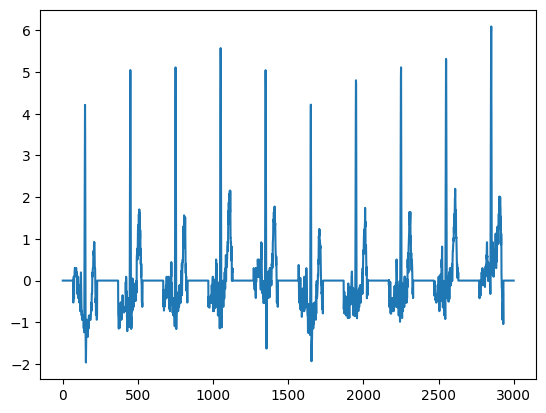

In [45]:
plt.plot(sig[0, :, 0])

In [ ]:
dict_report = {}
sub_id = 1
drop_trial = drop_trial + none_trial
for pid, tris in group.items():
    reports = []
    for tri in tris:
        tri_path = os.path.join(path, subset_list.loc[subset_list.study_id == tri].path.values[0])
        if tri_path in drop_trial:
            continue
        report = subset_measurement[subset_measurement["study_id"] == tri].iloc[:, 4:21].values[0]
        report = report[~pd.isna(report)].tolist()
        reports += report
    if reports != list():
        reports = set(reports)
        dict_report[sub_id] = list(reports)
        sub_id += 1
    else:
        print(f"The subject is None after preprocessing with the path {tri_path}")       

In [42]:
len(dict_report)

6826

In [43]:
np.save(os.path.join(label_path, "report"), dict_report)

In [44]:
reports = np.load(os.path.join(label_path, "report.npy"), allow_pickle=True).item()

In [45]:
reports

{1: ['Sinus rhythm',
  'Normal ECG except for rate',
  'Sinus tachycardia',
  'Possible right atrial abnormality',
  'Borderline ECG'],
 2: ['Sinus rhythm', 'Normal ECG'],
 3: ['Sinus rhythm'],
 4: ['Sinus rhythm',
  'Low QRS voltages in precordial leads',
  'Normal ECG',
  'Borderline ECG',
  "rSr'(V1) - probable normal variant"],
 5: ['Sinus rhythm with PAC(s).',
  'Sinus rhythm',
  'Extensive ST-T changes are nonspecific',
  'Extensive T wave changes are probably due to ventricular hypertrophy',
  'Extensive T wave changes may be due to myocardial ischemia',
  'Extensive T wave changes may be due to hypertrophy and/or ischemia',
  'Sinus bradycardia with interpolated PVC(s)',
  'Abnormal R-wave progression, early transition',
  'Abnormal ECG',
  'Possible left ventricular hypertrophy',
  'Borderline ECG',
  'Left ventricular hypertrophy',
  'Nonspecific T abnormalities, diffuse leads',
  'Sinus bradycardia',
  'Sinus bradycardia.',
  'Prolonged QT interval'],
 6: ['Extensive ST-T ch